In [1]:
import pandas as pd
import numpy as np
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
LipidsIntensity=pd.read_csv("/p1/data/jtian/SA/input/04_FindLipidsPeaks/LipidsAverageIntensity.csv")
print(LipidsIntensity.head(10))

         mz           0          15          30          45          60
0  402.2409   13.221297   14.786233   15.006417   15.450004   15.492122
1  403.2578   40.184364   48.387520   50.394665   50.718719   50.529148
2  404.2571   24.252378   26.635759   28.014132   28.404577   28.586966
3  405.2771   97.169403   99.608360   97.728188   95.302185   92.215508
4  406.2774   28.235029   29.515171   29.559731   29.130516   28.637997
5  407.2556   64.575966   68.771889   71.171845   72.227264   72.506294
6  408.2587   29.551786   30.361195   30.923071   31.241034   31.021654
7  409.2336  579.647339  648.542175  696.613770  735.481323  760.718445
8  410.2374  161.003891  173.212997  181.487183  187.960831  191.495178
9  415.2252  177.355484  262.517395  321.724762  359.606873  394.495148


In [10]:
intensity_cols = LipidsIntensity.columns[1:]

In [11]:
# 计算样本标准差 (ddof=1 确保使用 n-1 作为分母，即样本标准差)
LipidsIntensity['STDEV_S'] = LipidsIntensity[intensity_cols].std(axis=1, ddof=1)

In [12]:
# 计算样本均值
LipidsIntensity['MEAN'] = LipidsIntensity[intensity_cols].mean(axis=1)

In [13]:
# 计算 CV (变异系数，表示为百分比)
# CV = (样本标准差 / 均值) * 100
LipidsIntensity['CV (%)'] = (LipidsIntensity['STDEV_S'] / LipidsIntensity['MEAN']) * 100


--- 筛选结果: 变异系数 (CV) <= 10.0% 的稳定脂质 ---
总脂质数量: 464
稳定脂质数量: 336
       CV (%)        mz
291  1.181485  737.5365
72   1.191685  496.2654
378  1.368848  795.6350
429  1.438147  868.2897
13   1.461315  422.3022


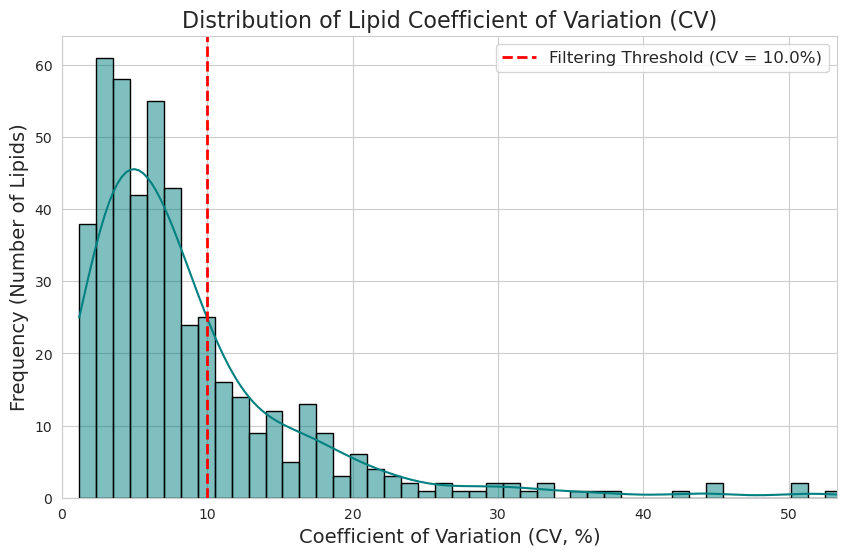


稳定脂质列表已保存至: /p1/data/jtian/SA/output/04_FindLipidsPeaks/stable_lipids_CV_analysis_10.csv


In [14]:
# --- 3. 筛选稳定脂质 (设定阈值) ---

# **设定 CV 筛选阈值 (您可以根据实验要求修改此值)**
CV_THRESHOLD = 10.0 

# 创建布尔掩码：选择 CV 小于或等于阈值的脂质
stable_lipids_mask = LipidsIntensity['CV (%)'] <= CV_THRESHOLD

# 应用筛选器
stable_lipids_df = LipidsIntensity[stable_lipids_mask].copy()

# 输出筛选结果
print("\n" + "="*60)
print(f"--- 筛选结果: 变异系数 (CV) <= {CV_THRESHOLD}% 的稳定脂质 ---")
print(f"总脂质数量: {len(LipidsIntensity)}")
print(f"稳定脂质数量: {len(stable_lipids_df)}")
print(stable_lipids_df[['CV (%)', LipidsIntensity.columns[0]]].sort_values(by='CV (%)').head())

# --- 4. 绘制 CV 值分布图 ---

# Set plot style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Plot Histogram and Kernel Density Estimate (KDE)
sns.histplot(
    LipidsIntensity['CV (%)'],
    bins=50,  # Number of bins
    kde=True,
    color='teal',
    edgecolor='black'
)

# Add threshold line
plt.axvline(
    CV_THRESHOLD,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Filtering Threshold (CV = {CV_THRESHOLD}%)'
)

# Set Title and Labels to English
plt.title('Distribution of Lipid Coefficient of Variation (CV)', fontsize=16)
plt.xlabel('Coefficient of Variation (CV, %)', fontsize=14)
plt.ylabel('Frequency (Number of Lipids)', fontsize=14)
plt.legend(fontsize=12)

# Set X-axis limit to focus on the core distribution (e.g., up to the 99th percentile)
# This prevents extreme outliers from compressing the main part of the histogram.
x_limit = LipidsIntensity['CV (%)'].quantile(0.99) * 1.2
if x_limit < CV_THRESHOLD * 2: # Ensure the limit is reasonable if 99% is too low
    x_limit = CV_THRESHOLD * 2.5
plt.xlim(0, x_limit) 

plt.show()

# --- 5. 结果保存 (可选) ---
output_path = "/p1/data/jtian/SA/output/04_FindLipidsPeaks/stable_lipids_CV_analysis_10.csv"
stable_lipids_df.to_csv(output_path, index=False)
print(f"\n稳定脂质列表已保存至: {output_path}")